In [177]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.neighbors import kneighbors_graph
from sklearn.neighbors import NearestNeighbors
from scipy.sparse.csgraph import connected_components

import pickle
from joblib import Parallel, delayed

# Load data

In [75]:
spatial = pd.read_csv(r"Y:\coskun-lab\Zhou\12_MSG\nanostring_xenium_comp\results\cell_type_annotation\v4\xenium_7202c_spatial_annotated.csv")

In [76]:
spatial

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,cell_types
0,aaaehcah-1,520.092896,1298.299194,384,0,0,0,0,384,206.996258,34.047814,Seromucous Acini
1,aaagbhce-1,531.737244,1319.697998,109,0,0,0,0,109,78.842815,NaN,Seromucous Acini
2,aaaggmkl-1,528.077515,1311.880249,59,0,0,0,0,59,38.382814,NaN,Seromucous Acini
3,aaahafkn-1,519.311279,1312.118896,301,0,0,0,0,301,156.330943,47.820470,Seromucous Acini
4,aaaoippf-1,592.664673,1326.881470,389,0,0,0,0,389,202.209695,27.861407,Mucous Acini
...,...,...,...,...,...,...,...,...,...,...,...,...
21732,ojadcbil-1,2358.630859,1939.707153,22,0,0,0,0,22,8.805469,6.863750,Stromal
21733,ojaeenef-1,2322.191406,1958.758057,30,0,0,0,0,30,33.280157,16.482032,Stromal
21734,ojagmnpm-1,2369.672607,2199.890869,295,0,0,0,0,295,152.718443,16.165938,Plasma cell
21735,ojanhjop-1,2345.888184,2113.256592,47,0,0,0,0,47,35.492814,6.592813,Stromal


# knn graph, filter outlier cells

In [ ]:
k = 5
adj_matrix = kneighbors_graph(spatial[['x_centroid','y_centroid']].values.astype('float'), n_neighbors=k, mode='connectivity', include_self=False)

In [78]:
adj_matrix

<21737x21737 sparse matrix of type '<class 'numpy.float64'>'
	with 108685 stored elements in Compressed Sparse Row format>

In [79]:
n_components, labels = connected_components(adj_matrix, directed=False)

In [80]:
np.unique(labels, return_counts=True)

(array([0], dtype=int32), array([21737]))

In [81]:
# Initially, only keep the largest subgraph, unless there are other large subgraphs
valid_components = [0]
valid_nodes = np.isin(labels, valid_components)
adj_matrix = adj_matrix[valid_nodes][:, valid_nodes]
filtered_points = spatial.iloc[valid_nodes]

In [82]:
filtered_points.reset_index(drop=True, inplace=True)

In [83]:
filtered_points.shape

(21737, 12)

In [84]:
adj_matrix.shape

(21737, 21737)

In [103]:
# Remove the longest k edges
n_components, labels = connected_components(adj_matrix, directed=False)
prev_n_components = n_components
while n_components == prev_n_components:
    distances = adj_matrix.data
    row, col = adj_matrix.nonzero()
    k_remove = 1
    longest_edge_indices = np.argsort(distances)[-k_remove:]

    for idx in longest_edge_indices:
        adj_matrix[row[idx], col[idx]] = 0
        adj_matrix[col[idx], row[idx]] = 0
    adj_matrix.eliminate_zeros()
    n_components, labels = connected_components(adj_matrix, directed=False)

In [104]:
np.unique(labels, return_counts=True)

(array([0, 1], dtype=int32), array([21732,     2]))

In [105]:
# Long edges and associated small subgraphs are removed here
valid_components = [0]
valid_nodes = np.isin(labels, valid_components)
adj_matrix = adj_matrix[valid_nodes][:, valid_nodes]
filtered_points = filtered_points.iloc[valid_nodes]
filtered_points.reset_index(drop=True, inplace=True)

In [106]:
filtered_points.shape

(21732, 12)

(np.float64(389.32218780517576),
 np.float64(2926.4144149780273),
 np.float64(34.17833175659179),
 np.float64(2422.3746925354003))

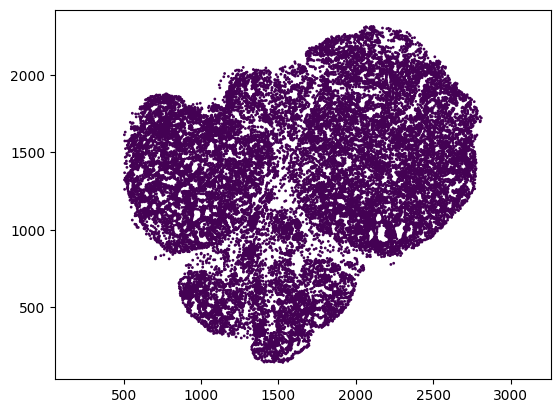

In [130]:
# visually inspect the graph
plt.scatter(filtered_points['x_centroid'], filtered_points['y_centroid'], c=labels[valid_nodes], s=1)
plt.axis('equal')

In [131]:
filtered_points.shape

(21732, 12)

In [132]:
filtered_points.to_csv(r'..\..\results\graph_classification_v5\xenium\xenium_7202c_spatial_annotation_filtered.csv', index=False)

## find unique edges xenium

In [238]:
filtered_points = pd.read_csv(r'..\..\results\graph_classification_v5\xenium\xenium_7202d_spatial_annotation_filtered.csv')

In [239]:
adj_matrix = kneighbors_graph(filtered_points[['x_centroid','y_centroid']].values.astype('float'), n_neighbors=k, mode='connectivity', include_self=False)

adj_matrix = adj_matrix.maximum(adj_matrix.T)

row,col = adj_matrix.nonzero()
edges = np.column_stack((row,col))
unique_edges = edges[edges[:, 0] < edges[:, 1]]

In [240]:
with open(r'..\..\results\graph_classification_v5\xenium\xenium_7202d_spatial_annotation_filtered_edges.pkl', 'wb') as f:
    pickle.dump(unique_edges, f)

## find unique edges cosmx

In [257]:
filtered_points = pd.read_csv(r'..\..\results\graph_classification_v5\cosmx\cosmx_72022_spatial_annotation_filtered.csv')

In [258]:
adj_matrix = kneighbors_graph(filtered_points[['CenterX_global_px','CenterY_global_px']].values.astype('float'), n_neighbors=k, mode='connectivity', include_self=False)

adj_matrix = adj_matrix.maximum(adj_matrix.T)

row,col = adj_matrix.nonzero()
edges = np.column_stack((row,col))
unique_edges = edges[edges[:, 0] < edges[:, 1]]

In [259]:
with open(r'..\..\results\graph_classification_v5\cosmx\cosmx_72022_spatial_annotation_filtered_edges.pkl', 'wb') as f:
    pickle.dump(unique_edges, f)

# extract 2-hop subgraphs around stromal cells

## example and 83a

In [260]:
filtered_points = pd.read_csv(r'..\..\results\graph_classification_v5\xenium\xenium_83a_spatial_annotation_filtered.csv')
unique_edges = pd.read_pickle(r'..\..\results\graph_classification_v5\xenium\xenium_83a_spatial_annotation_filtered_edges.pkl')

In [261]:
filtered_points.shape

(71750, 12)

In [262]:
def one_hop_neighbors(cell, cell_metadata, edges):
    idx = cell_metadata.index.get_loc(cell)
    neighbors = set()
    for edge in edges:
        if edge[0] == idx:
            neighbors.add(edge[1])
        elif edge[1] == idx:
            neighbors.add(edge[0])
    # neighbor_cells = []
    # for items in neighbors:
    #     neighbor_cells.append(cell_metadata.index[items])
    return list(neighbors)

def two_hop_neighbors(cell, cell_metadata, edges):
    one_hop = one_hop_neighbors(cell, cell_metadata, edges)
    two_hop = set()

    for neighbor in one_hop:
        two_hop.update(one_hop_neighbors(neighbor, cell_metadata, edges))
    
    two_hop.update(one_hop)
    # two_hop.discard(cell_metadata.index.get_loc(cell))
    return list(two_hop)

def edges_in_subgraph(neighborhood, edges):
    neighborhood = set(neighborhood)
    subgraph_edges = []
    for edge in edges:
        if edge[0] in neighborhood and edge[1] in neighborhood:
            subgraph_edges.append(edge)
    return subgraph_edges

In [263]:
from collections import defaultdict, deque

def build_adjacency_list(edges, num_nodes):
    adj = defaultdict(set)
    for u, v in edges:
        adj[u].add(v)
        adj[v].add(u)
    return adj

def k_hop_neighbors(cell, cell_metadata, edges, k):
    idx = cell_metadata.index.get_loc(cell)
    num_nodes = len(cell_metadata)
    adj = build_adjacency_list(edges, num_nodes)

    visited = set([idx])
    queue = deque([(idx, 0)])
    
    while queue:
        current, depth = queue.popleft()
        if depth >= k:
            continue
        for neighbor in adj[current]:
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append((neighbor, depth + 1))

    return list(visited)


In [264]:
cells = filtered_points[filtered_points['cell_types'] == 'Stromal']
cells_idx = cells.index.tolist()

In [265]:
i = 155
two_hop = k_hop_neighbors(cells_idx[155], filtered_points, unique_edges, 2)

In [266]:
cells_idx[155]

22433

In [267]:
filtered_points.iloc[cells_idx[155]]

cell_id                        ejedhmpn-1
x_centroid                     232.297623
y_centroid                    2260.197998
transcript_counts                      33
control_probe_counts                    0
control_codeword_counts                 0
unassigned_codeword_counts              0
deprecated_codeword_counts              0
total_counts                           33
cell_area                       20.907345
nucleus_area                    13.095313
cell_types                        Stromal
Name: 22433, dtype: object

In [268]:
edges = edges_in_subgraph(two_hop, unique_edges)

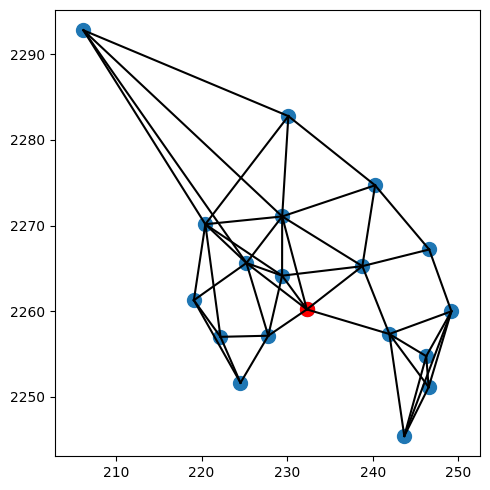

In [269]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
for edge in edges:
    ax.plot(filtered_points['x_centroid'].iloc[edge], filtered_points['y_centroid'].iloc[edge], c='black')
ax.scatter(filtered_points['x_centroid'].iloc[two_hop], filtered_points['y_centroid'].iloc[two_hop], s=100)
ax.scatter(filtered_points['x_centroid'].iloc[cells_idx[i]], filtered_points['y_centroid'].iloc[cells_idx[i]], c='red', s=100)

ax.axis('equal')
plt.tight_layout()
# plt.savefig(r'..\..\figures\graph_classification\stromal_subgraph.png', dpi=300)

In [270]:
filtered_points.iloc[edges[0][0]]['cell_id']

'ejdhenkh-1'

In [271]:
edges_by_id = []
for item in edges:
    edges_by_id.append((filtered_points.iloc[item[0]]['cell_id'], filtered_points.iloc[item[1]]['cell_id'])) 

In [272]:
# Processing function
def sub_graphs(cell, cell_metadata, edges):
    two_hop = k_hop_neighbors(cell, cell_metadata, edges, 2)

    two_hop_edges = edges_in_subgraph(two_hop, edges)
    two_hop_edges_by_id = []
    for item in two_hop_edges:
        two_hop_edges_by_id.append((cell_metadata.iloc[item[0]]['cell_id'], cell_metadata.iloc[item[1]]['cell_id']))

    return two_hop_edges_by_id

In [273]:
sub_graphs_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, filtered_points, unique_edges) for cell in cells_idx)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    3.7s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    3.7s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    3.7s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    3.8s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    3.8s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    3.9s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    3.9s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    3.9s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-3)]: Done  14 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-3)]: Done  15 tasks      | elapsed:  

In [274]:
with open(r'..\..\results\graph_classification_v5\xenium\sub_graphs_83a.pkl', 'wb') as f:
    pickle.dump(sub_graphs_l, f)

In [275]:
with open(r'..\..\results\graph_classification_v5\xenium\sub_graphs_83a_cell_index.pkl', 'wb') as f:
    pickle.dump(cells_idx, f)

## 83b

In [276]:
filtered_points = pd.read_csv(r'..\..\results\graph_classification_v5\xenium\xenium_83b_spatial_annotation_filtered.csv')
unique_edges = pd.read_pickle(r'..\..\results\graph_classification_v5\xenium\xenium_83b_spatial_annotation_filtered_edges.pkl')

In [277]:
filtered_points.shape

(72247, 12)

In [278]:
cells = filtered_points[filtered_points['cell_types'] == 'Stromal']
cells_idx = cells.index.tolist()

In [279]:
sub_graph_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, filtered_points, unique_edges) for cell in cells_idx)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-3)]: Done  14 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-3)]: Done  15 tasks      | elapsed:  

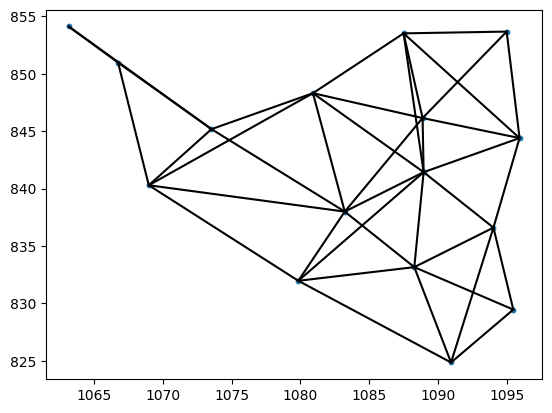

In [280]:
nodes_to_plot = sub_graph_l[0]
nodes = filtered_points[filtered_points['cell_id'].isin(np.unique(nodes_to_plot))]
plt.scatter(nodes['x_centroid'], nodes['y_centroid'], s=10)
for edge in nodes_to_plot:
    node1 = edge[0]
    node2 = edge[1]
    plt.plot([filtered_points[filtered_points['cell_id'] == node1]['x_centroid'].values[0], filtered_points[filtered_points['cell_id'] == node2]['x_centroid'].values[0]],
             [filtered_points[filtered_points['cell_id'] == node1]['y_centroid'].values[0], filtered_points[filtered_points['cell_id'] == node2]['y_centroid'].values[0]], c='black')

In [281]:
with open(r'..\..\results\graph_classification_v5\xenium\sub_graphs_83b.pkl', 'wb') as f:
    pickle.dump(sub_graph_l, f)

In [282]:
with open(r'..\..\results\graph_classification_v5\xenium\sub_graphs_83b_cell_index.pkl', 'wb') as f:
    pickle.dump(cells_idx, f)

## 84a

In [283]:
filtered_points = pd.read_csv(r'..\..\results\graph_classification_v5\xenium\xenium_84a_spatial_annotation_filtered.csv')
unique_edges = pd.read_pickle(r'..\..\results\graph_classification_v5\xenium\xenium_84a_spatial_annotation_filtered_edges.pkl')

In [284]:
filtered_points.shape

(67150, 12)

In [285]:
cells = filtered_points[filtered_points['cell_types'] == 'Stromal']
cells_idx = cells.index.tolist()

In [286]:
sub_graph_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, filtered_points, unique_edges) for cell in cells_idx)


[Parallel(n_jobs=-3)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-3)]: Done  14 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-3)]: Done  15 tasks      | elapsed:  

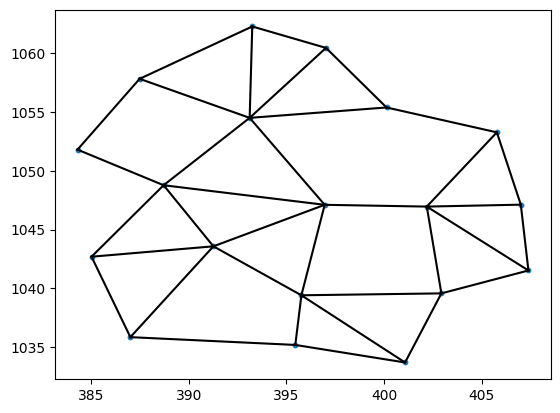

In [287]:
nodes_to_plot = sub_graph_l[0]
nodes = filtered_points[filtered_points['cell_id'].isin(np.unique(nodes_to_plot))]
plt.scatter(nodes['x_centroid'], nodes['y_centroid'], s=10)
for edge in nodes_to_plot:
    node1 = edge[0]
    node2 = edge[1]
    plt.plot([filtered_points[filtered_points['cell_id'] == node1]['x_centroid'].values[0], filtered_points[filtered_points['cell_id'] == node2]['x_centroid'].values[0]],
             [filtered_points[filtered_points['cell_id'] == node1]['y_centroid'].values[0], filtered_points[filtered_points['cell_id'] == node2]['y_centroid'].values[0]], c='black')

In [288]:
with open(r'..\..\results\graph_classification_v5\xenium\sub_graphs_84a.pkl', 'wb') as f:
    pickle.dump(sub_graph_l, f)

In [289]:
with open(r'..\..\results\graph_classification_v5\xenium\sub_graphs_84a_cell_index.pkl', 'wb') as f:
    pickle.dump(cells_idx, f)

## 84b

In [290]:
filtered_points = pd.read_csv(r'..\..\results\graph_classification_v5\xenium\xenium_84b_spatial_annotation_filtered.csv')
unique_edges = pd.read_pickle(r'..\..\results\graph_classification_v5\xenium\xenium_84b_spatial_annotation_filtered_edges.pkl')

In [291]:
filtered_points.shape

(67393, 12)

In [292]:
cells = filtered_points[filtered_points['cell_types'] == 'Stromal']
cells_idx = cells.index.tolist()

In [293]:
sub_graph_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, filtered_points, unique_edges) for cell in cells_idx)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-3)]: Done  14 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-3)]: Done  15 tasks      | elapsed:  

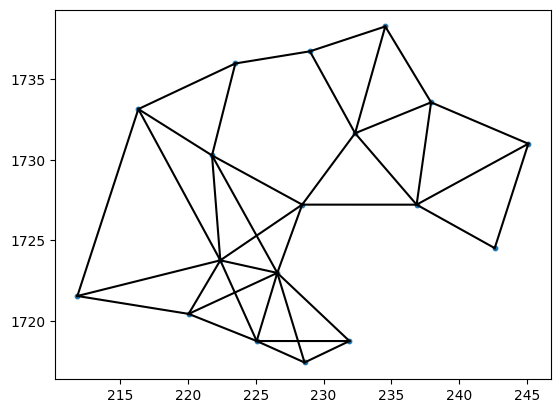

In [294]:
nodes_to_plot = sub_graph_l[0]
nodes = filtered_points[filtered_points['cell_id'].isin(np.unique(nodes_to_plot))]
plt.scatter(nodes['x_centroid'], nodes['y_centroid'], s=10)
for edge in nodes_to_plot:
    node1 = edge[0]
    node2 = edge[1]
    plt.plot([filtered_points[filtered_points['cell_id'] == node1]['x_centroid'].values[0], filtered_points[filtered_points['cell_id'] == node2]['x_centroid'].values[0]],
             [filtered_points[filtered_points['cell_id'] == node1]['y_centroid'].values[0], filtered_points[filtered_points['cell_id'] == node2]['y_centroid'].values[0]], c='black')

In [295]:
with open(r'..\..\results\graph_classification_v5\xenium\sub_graphs_84b.pkl', 'wb') as f:
    pickle.dump(sub_graph_l, f)

In [296]:
with open(r'..\..\results\graph_classification_v5\xenium\sub_graphs_84b_cell_index.pkl', 'wb') as f:
    pickle.dump(cells_idx, f)

## 174c

In [297]:
filtered_points = pd.read_csv(r'..\..\results\graph_classification_v5\xenium\xenium_174c_spatial_annotation_filtered.csv')
unique_edges = pd.read_pickle(r'..\..\results\graph_classification_v5\xenium\xenium_174c_spatial_annotation_filtered_edges.pkl')

In [298]:
filtered_points.shape

(16654, 12)

In [299]:
cells = filtered_points[filtered_points['cell_types'] == 'Stromal']
cells_idx = cells.index.tolist()

In [300]:
sub_graph_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, filtered_points, unique_edges) for cell in cells_idx)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.10476231575012207s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]

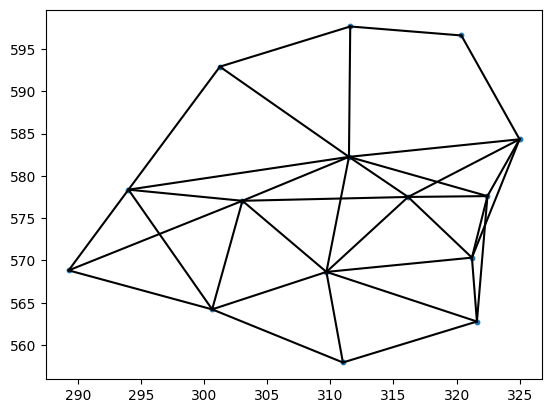

In [301]:
nodes_to_plot = sub_graph_l[0]
nodes = filtered_points[filtered_points['cell_id'].isin(np.unique(nodes_to_plot))]
plt.scatter(nodes['x_centroid'], nodes['y_centroid'], s=10)
for edge in nodes_to_plot:
    node1 = edge[0]
    node2 = edge[1]
    plt.plot([filtered_points[filtered_points['cell_id'] == node1]['x_centroid'].values[0], filtered_points[filtered_points['cell_id'] == node2]['x_centroid'].values[0]],
             [filtered_points[filtered_points['cell_id'] == node1]['y_centroid'].values[0], filtered_points[filtered_points['cell_id'] == node2]['y_centroid'].values[0]], c='black')

In [302]:
with open(r'..\..\results\graph_classification_v5\xenium\sub_graphs_174c.pkl', 'wb') as f:
    pickle.dump(sub_graph_l, f)

In [303]:
with open(r'..\..\results\graph_classification_v5\xenium\sub_graphs_174c_cell_index.pkl', 'wb') as f:
    pickle.dump(cells_idx, f)

## 174d

In [304]:
filtered_points = pd.read_csv(r'..\..\results\graph_classification_v5\xenium\xenium_174d_spatial_annotation_filtered.csv')
unique_edges = pd.read_pickle(r'..\..\results\graph_classification_v5\xenium\xenium_174d_spatial_annotation_filtered_edges.pkl')

In [305]:
filtered_points.shape

(16469, 12)

In [306]:
cells = filtered_points[filtered_points['cell_types'] == 'Stromal']
cells_idx = cells.index.tolist()

In [307]:
sub_graph_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, filtered_points, unique_edges) for cell in cells_idx)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.09654474258422852s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]

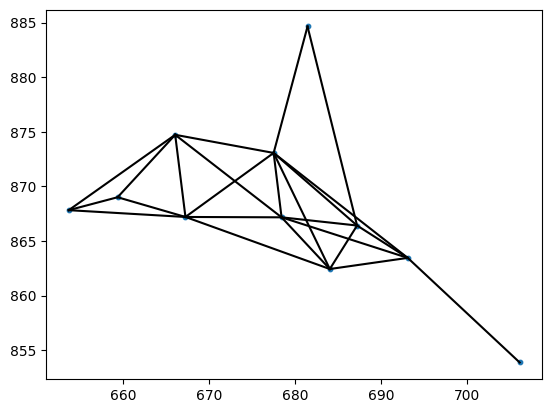

In [308]:
nodes_to_plot = sub_graph_l[0]
nodes = filtered_points[filtered_points['cell_id'].isin(np.unique(nodes_to_plot))]
plt.scatter(nodes['x_centroid'], nodes['y_centroid'], s=10)
for edge in nodes_to_plot:
    node1 = edge[0]
    node2 = edge[1]
    plt.plot([filtered_points[filtered_points['cell_id'] == node1]['x_centroid'].values[0], filtered_points[filtered_points['cell_id'] == node2]['x_centroid'].values[0]],
             [filtered_points[filtered_points['cell_id'] == node1]['y_centroid'].values[0], filtered_points[filtered_points['cell_id'] == node2]['y_centroid'].values[0]], c='black')

In [309]:
with open(r'..\..\results\graph_classification_v5\xenium\sub_graphs_174d.pkl', 'wb') as f:
    pickle.dump(sub_graph_l, f)

In [310]:
with open(r'..\..\results\graph_classification_v5\xenium\sub_graphs_174d_cell_index.pkl', 'wb') as f:
    pickle.dump(cells_idx, f)

## 7202c

In [383]:
filtered_points = pd.read_csv(r'..\..\results\graph_classification_v5\xenium\xenium_7202c_spatial_annotation_filtered.csv')
unique_edges = pd.read_pickle(r'..\..\results\graph_classification_v5\xenium\xenium_7202c_spatial_annotation_filtered_edges.pkl')

In [384]:
filtered_points.shape

(21732, 12)

In [385]:
cells = filtered_points[filtered_points['cell_types'] == 'Stromal']
cells_idx = cells.index.tolist()

In [386]:
filtered_points['cell_types'].value_counts()

cell_types
Mucous Acini         5776
Seromucous Acini     4302
Stromal              3760
Ductal Epithelial    2348
Plasma cell          1609
Endothelial cell     1201
CD8 T-cell            944
Macrophage            860
B-cell                748
Mast cell             184
Name: count, dtype: int64

In [387]:
sub_graph_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, filtered_points, unique_edges) for cell in cells_idx)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-3)]: Done  14 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-3)]: Done  15 tasks      | elapsed:  

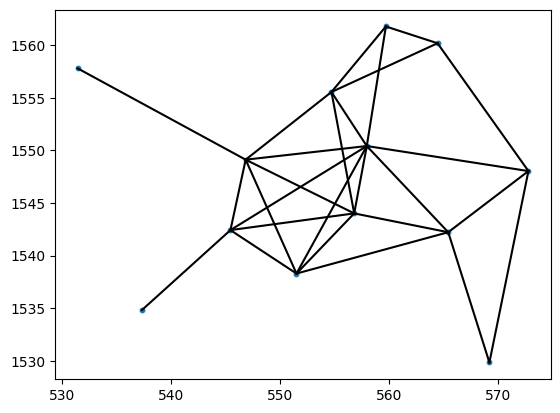

In [388]:
nodes_to_plot = sub_graph_l[0]
nodes = filtered_points[filtered_points['cell_id'].isin(np.unique(nodes_to_plot))]
plt.scatter(nodes['x_centroid'], nodes['y_centroid'], s=10)
for edge in nodes_to_plot:
    node1 = edge[0]
    node2 = edge[1]
    plt.plot([filtered_points[filtered_points['cell_id'] == node1]['x_centroid'].values[0], filtered_points[filtered_points['cell_id'] == node2]['x_centroid'].values[0]],
             [filtered_points[filtered_points['cell_id'] == node1]['y_centroid'].values[0], filtered_points[filtered_points['cell_id'] == node2]['y_centroid'].values[0]], c='black')

In [389]:
with open(r'..\..\results\graph_classification_v5\xenium\sub_graphs_7202c.pkl', 'wb') as f:
    pickle.dump(sub_graph_l, f)

In [390]:
with open(r'..\..\results\graph_classification_v5\xenium\sub_graphs_7202c_cell_index.pkl', 'wb') as f:
    pickle.dump(cells_idx, f)

## 7202d

In [319]:
filtered_points = pd.read_csv(r'..\..\results\graph_classification_v5\xenium\xenium_7202d_spatial_annotation_filtered.csv')
unique_edges = pd.read_pickle(r'..\..\results\graph_classification_v5\xenium\xenium_7202d_spatial_annotation_filtered_edges.pkl')

In [320]:
filtered_points.shape

(20994, 12)

In [321]:
cells = filtered_points[filtered_points['cell_types'] == 'Stromal']
cells_idx = cells.index.tolist()

In [322]:
sub_graph_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, filtered_points, unique_edges) for cell in cells_idx)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.13928985595703125s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]

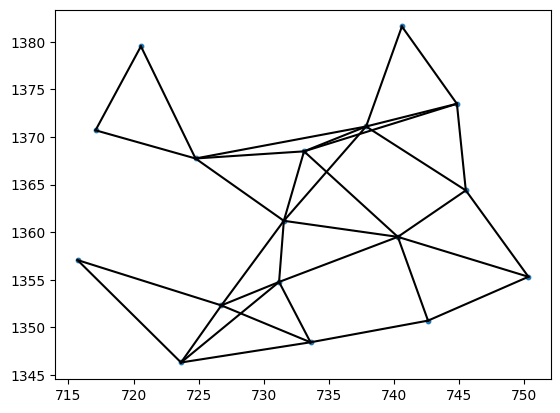

In [323]:
nodes_to_plot = sub_graph_l[0]
nodes = filtered_points[filtered_points['cell_id'].isin(np.unique(nodes_to_plot))]
plt.scatter(nodes['x_centroid'], nodes['y_centroid'], s=10)
for edge in nodes_to_plot:
    node1 = edge[0]
    node2 = edge[1]
    plt.plot([filtered_points[filtered_points['cell_id'] == node1]['x_centroid'].values[0], filtered_points[filtered_points['cell_id'] == node2]['x_centroid'].values[0]],
             [filtered_points[filtered_points['cell_id'] == node1]['y_centroid'].values[0], filtered_points[filtered_points['cell_id'] == node2]['y_centroid'].values[0]], c='black')

In [324]:
with open(r'..\..\results\graph_classification_v5\xenium\sub_graphs_7202d.pkl', 'wb') as f:
    pickle.dump(sub_graph_l, f)

In [325]:
with open(r'..\..\results\graph_classification_v5\xenium\sub_graphs_7202d_cell_index.pkl', 'wb') as f:
    pickle.dump(cells_idx, f)

# Cosmx

# filter ourlier points

In [342]:
# spatial = pd.read_csv(r"Y:\coskun-lab\Zhou\12_MSG\nanostring_xenium_comp\results\cell_type_annotation\v4\cosmx_72022_spatial_annotated.csv")

In [343]:
# plt.scatter(spatial['CenterX_global_px'].tolist(), spatial['CenterY_global_px'].tolist())

In [344]:
# k = 5
# adj_matrix = kneighbors_graph(spatial[['CenterX_global_px','CenterY_global_px']].values.astype('float'), n_neighbors=k, mode='distance', include_self=False)

In [345]:
# n_components, labels = connected_components(adj_matrix, directed=False)

In [346]:
# np.unique(labels, return_counts=True)

In [347]:
# filtered_points = spatial

In [348]:
# # Initially, only keep the largest subgraph, unless there are other large subgraphs
# valid_components = [0,1]
# valid_nodes = np.isin(labels, valid_components)
# adj_matrix = adj_matrix[valid_nodes][:, valid_nodes]
# filtered_points = spatial.iloc[valid_nodes]

In [349]:
# filtered_points.reset_index(drop=True, inplace=True)

In [350]:
# filtered_points.shape

In [351]:
# adj_matrix.shape

In [352]:
# # Remove the longest k edges
# n_components, labels = connected_components(adj_matrix, directed=False)
# pre_n_components = n_components
# while n_components == pre_n_components:
#     distances = adj_matrix.data
#     row, col = adj_matrix.nonzero()
#     k_remove = 1
#     longest_edge_indices = np.argsort(distances)[-k_remove:]

#     for idx in longest_edge_indices:
#         adj_matrix[row[idx], col[idx]] = 0
#         adj_matrix[col[idx], row[idx]] = 0
#     adj_matrix.eliminate_zeros()
#     n_components, labels = connected_components(adj_matrix, directed=False)

In [353]:
# np.unique(labels, return_counts=True)

In [354]:
# # Long edges and associated small subgraphs are removed here
# valid_components = [0,2]
# valid_nodes = np.isin(labels, valid_components)
# adj_matrix = adj_matrix[valid_nodes][:, valid_nodes]
# filtered_points = filtered_points.iloc[valid_nodes]
# filtered_points.reset_index(drop=True, inplace=True)

In [355]:
# filtered_points.shape

In [356]:
# # visually inspect the graph
# plt.scatter(filtered_points['CenterX_global_px'], filtered_points['CenterY_global_px'])#, c=labels[valid_nodes])
# plt.axis('equal')

In [357]:
# filtered_points.to_csv(r'..\..\results\graph_classification_v4\cosmx\cosmx_72022_spatial_annotation_filtered.csv', index=False)

In [358]:
# row,col = adj_matrix.nonzero()
# edges = np.column_stack((row,col))
# unique_edges = edges[edges[:, 0] < edges[:, 1]]

In [359]:
# with open(r'..\..\results\graph_classification_v4\cosmx\cosmx_72022_spatial_annotation_filtered_edges.pkl', 'wb') as f:
#     pickle.dump(unique_edges, f)

# subgraphs and 2-hop neighbors

## example, 83

In [326]:
filtered_points = pd.read_csv(r'..\..\results\graph_classification_v5\cosmx\cosmx_83_spatial_annotation_filtered.csv')
unique_edges = pd.read_pickle(r'..\..\results\graph_classification_v5\cosmx\cosmx_83_spatial_annotation_filtered_edges.pkl')

In [327]:
cells = filtered_points[filtered_points['cell_types'] == 'Stromal']
cells_idx = cells.index.tolist()

In [328]:
i = 155
two_hop = two_hop_neighbors(cells_idx[155], filtered_points, unique_edges)

In [329]:
cells_idx[155]

2301

In [330]:
filtered_points.iloc[cells_idx[155]]

nn_c22bd556.a090.4960.aaf6.663575c4a986_1_cluster_cluster_4706a76d.e651.42a6.9acf.c20f98f133ea_1            9
RNA_nbclust_38c7d26d.96fb.493d.9c96.8e4997c19409_1_clusters                                                 b
RNA_nbclust_38c7d26d.96fb.493d.9c96.8e4997c19409_1_posterior_probability                             0.986454
cell                                                                                                c_1_5_189
nCount_RNA                                                                                                 96
                                                                                                      ...    
RNA_spatialclust_87edd0fb.e601.4f90.8048.3e06ffe3e684_1_neighbours_j                                        6
RNA_spatialclust_87edd0fb.e601.4f90.8048.3e06ffe3e684_1_neighbours_k                                        2
RNA_spatialclust_87edd0fb.e601.4f90.8048.3e06ffe3e684_1_neighbours_l                                        0
spatialclu

In [331]:
edges = edges_in_subgraph(two_hop, unique_edges)

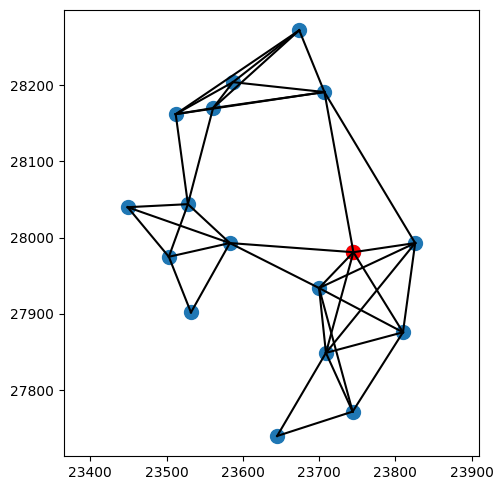

In [332]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
for edge in edges:
    ax.plot(filtered_points['CenterX_global_px'].iloc[edge], filtered_points['CenterY_global_px'].iloc[edge], c='black')
ax.scatter(filtered_points['CenterX_global_px'].iloc[two_hop], filtered_points['CenterY_global_px'].iloc[two_hop], s=100)
ax.scatter(filtered_points['CenterX_global_px'].iloc[cells_idx[i]], filtered_points['CenterY_global_px'].iloc[cells_idx[i]], c='red', s=100)

ax.axis('equal')
plt.tight_layout()
# plt.savefig(r'..\..\figures\graph_classification\stromal_subgraph.png', dpi=300)

In [333]:
sub_graphs_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, filtered_points, unique_edges) for cell in cells_idx)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-3)]: Done  14 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-3)]: Done  15 tasks      | elapsed:  

In [334]:
with open(r'..\..\results\graph_classification_v5\cosmx\sub_graphs_83.pkl', 'wb') as f:
    pickle.dump(sub_graphs_l, f)

In [335]:
with open(r'..\..\results\graph_classification_v5\cosmx\sub_graphs_83_cell_index.pkl', 'wb') as f:
    pickle.dump(cells_idx, f)

## 84

In [392]:
filtered_points = pd.read_csv(r'..\..\results\graph_classification_v5\cosmx\cosmx_84_spatial_annotation_filtered.csv')
unique_edges = pd.read_pickle(r'..\..\results\graph_classification_v5\cosmx\cosmx_84_spatial_annotation_filtered_edges.pkl')

In [393]:
cells = filtered_points[filtered_points['cell_types'] == 'Stromal']
cells_idx = cells.index.tolist()

In [394]:
sub_graph_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, filtered_points, unique_edges) for cell in cells_idx)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.15936851501464844s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-3)]

In [400]:
nodes_to_plot

[('c_1_1_1', 'c_1_1_7'),
 ('c_1_1_1', 'c_1_1_3'),
 ('c_1_1_1', 'c_1_1_10'),
 ('c_1_1_1', 'c_1_1_4'),
 ('c_1_1_1', 'c_1_1_5'),
 ('c_1_1_3', 'c_1_1_10'),
 ('c_1_1_3', 'c_1_1_9'),
 ('c_1_1_3', 'c_1_1_5'),
 ('c_1_1_3', 'c_1_1_8'),
 ('c_1_1_4', 'c_1_1_13'),
 ('c_1_1_4', 'c_1_1_5'),
 ('c_1_1_4', 'c_1_1_10'),
 ('c_1_1_4', 'c_1_1_11'),
 ('c_1_1_4', 'c_1_1_12'),
 ('c_1_1_4', 'c_1_1_7'),
 ('c_1_1_5', 'c_1_1_8'),
 ('c_1_1_5', 'c_1_1_10'),
 ('c_1_1_7', 'c_1_1_11'),
 ('c_1_1_7', 'c_1_1_13'),
 ('c_1_1_7', 'c_1_1_12'),
 ('c_1_1_8', 'c_1_1_15'),
 ('c_1_1_8', 'c_1_1_9'),
 ('c_1_1_10', 'c_1_1_12'),
 ('c_1_1_10', 'c_1_1_15'),
 ('c_1_1_10', 'c_1_1_11'),
 ('c_1_1_11', 'c_1_1_13'),
 ('c_1_1_11', 'c_1_1_15'),
 ('c_1_1_11', 'c_1_1_12'),
 ('c_1_1_12', 'c_1_1_13')]

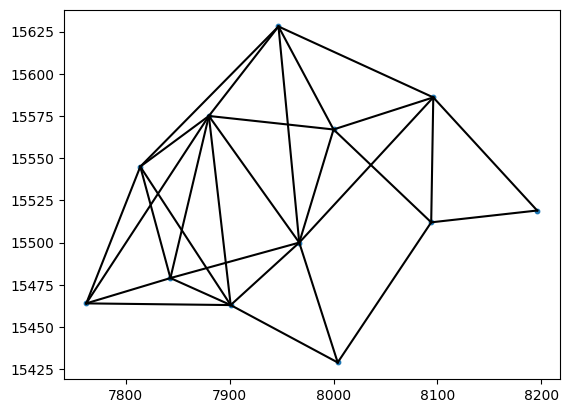

In [401]:
nodes_to_plot = sub_graph_l[0]
nodes = filtered_points[filtered_points['cell_id'].isin(np.unique(nodes_to_plot))]
plt.scatter(nodes['CenterX_global_px'], nodes['CenterY_global_px'], s=10)
for edge in nodes_to_plot:
    node1 = edge[0]
    node2 = edge[1]
    plt.plot([filtered_points[filtered_points['cell_id'] == node1]['CenterX_global_px'].values[0], filtered_points[filtered_points['cell_id'] == node2]['CenterX_global_px'].values[0]],
             [filtered_points[filtered_points['cell_id'] == node1]['CenterY_global_px'].values[0], filtered_points[filtered_points['cell_id'] == node2]['CenterY_global_px'].values[0]], c='black')

In [402]:
with open(r'..\..\results\graph_classification_v5\cosmx\sub_graphs_84.pkl', 'wb') as f:
    pickle.dump(sub_graph_l, f)

In [403]:
with open(r'..\..\results\graph_classification_v5\cosmx\sub_graphs_84_cell_index.pkl', 'wb') as f:
    pickle.dump(cells_idx, f)

## 174-1

In [422]:
filtered_points = pd.read_csv(r'..\..\results\graph_classification_v5\cosmx\cosmx_1741_spatial_annotation_filtered.csv')
unique_edges = pd.read_pickle(r'..\..\results\graph_classification_v5\cosmx\cosmx_1741_spatial_annotation_filtered_edges.pkl')

In [423]:
cells = filtered_points[filtered_points['cell_types'] == 'Stromal']
cells_idx = cells.index.tolist()

In [425]:
len(sub_graphs(cells_idx[0], filtered_points, unique_edges))

31

In [411]:
sub_graphs_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, filtered_points, unique_edges) for cell in cells_idx)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.0340266227722168s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 out of  34 | elapsed:    0.0s remaining:    0.6s
[Parallel(n_jobs=-3)]: Done   3 out of  34 | elapsed:    0.0s remaining:    0.4s
[Parallel(n_jobs=-3)]: Done   4 out of  34 | elapsed:    0.0s remaining:    0.3s
[Parallel(n_jobs=-3)]: Done   5 out of  34 | elapsed:    0.0s remaining:    0.3s
[Parallel(n_jobs=-3)]: Done   6 out of  34 | elapsed:    0.0s remaining:    0.2s
[Parallel(n_jobs=-3)]: Done   7 out of  34 | elapsed:    0.0s remaining:    0.2s
[Parallel(n_jobs=-3)]: Done   8 out of  34 | elapsed:    0.0s remaining:    0.2s
[Parallel(n_jobs=-3)]: Done   9 out of  34 | elapsed:    0.0s remaining:    0.2s
[Parallel(n_jobs=-3)]: Done  10 out of  34 | elapsed:    0.0s remaining:    0.1s
[Parallel(n_jobs=-3)]: Done  11 out o

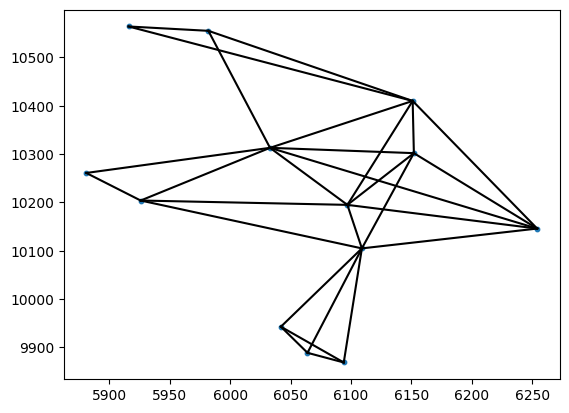

In [426]:
nodes_to_plot = sub_graphs_l[1]
nodes = filtered_points[filtered_points['cell_id'].isin(np.unique(nodes_to_plot))]
plt.scatter(nodes['CenterX_global_px'], nodes['CenterY_global_px'], s=10)
for edge in nodes_to_plot:
    node1 = edge[0]
    node2 = edge[1]
    plt.plot([filtered_points[filtered_points['cell_id'] == node1]['CenterX_global_px'].values[0], filtered_points[filtered_points['cell_id'] == node2]['CenterX_global_px'].values[0]],
             [filtered_points[filtered_points['cell_id'] == node1]['CenterY_global_px'].values[0], filtered_points[filtered_points['cell_id'] == node2]['CenterY_global_px'].values[0]], c='black')

In [427]:
with open(r'..\..\results\graph_classification_v5\cosmx\sub_graphs_1741.pkl', 'wb') as f:
    pickle.dump(sub_graphs_l, f)

In [428]:
with open(r'..\..\results\graph_classification_v5\cosmx\sub_graphs_1741_cell_index.pkl', 'wb') as f:
    pickle.dump(cells_idx, f)

## 174-2

In [429]:
filtered_points = pd.read_csv(r'..\..\results\graph_classification_v5\cosmx\cosmx_1742_spatial_annotation_filtered.csv')
unique_edges = pd.read_pickle(r'..\..\results\graph_classification_v5\cosmx\cosmx_1742_spatial_annotation_filtered_edges.pkl')

In [430]:
cells = filtered_points[filtered_points['cell_types'] == 'Stromal']
cells_idx = cells.index.tolist()

In [431]:
sub_graphs_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, filtered_points, unique_edges) for cell in cells_idx)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.041538238525390625s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 out of  45 | elapsed:    0.0s remaining:    1.1s
[Parallel(n_jobs=-3)]: Done   3 out of  45 | elapsed:    0.0s remaining:    0.7s
[Parallel(n_jobs=-3)]: Done   4 out of  45 | elapsed:    0.0s remaining:    0.5s
[Parallel(n_jobs=-3)]: Done   5 out of  45 | elapsed:    0.0s remaining:    0.5s
[Parallel(n_jobs=-3)]: Done   6 out of  45 | elapsed:    0.0s remaining:    0.4s
[Parallel(n_jobs=-3)]: Done   7 out of  45 | elapsed:    0.0s remaining:    0.4s
[Parallel(n_jobs=-3)]: Done   8 out of  45 | elapsed:    0.0s remaining:    0.3s
[Parallel(n_jobs=-3)]: Done   9 out of  45 | elapsed:    0.0s remaining:    0.3s
[Parallel(n_jobs=-3)]: Done  10 out of  45 | elapsed:    0.0s remaining:    0.2s
[Parallel(n_jobs=-3)]: Done  11 out

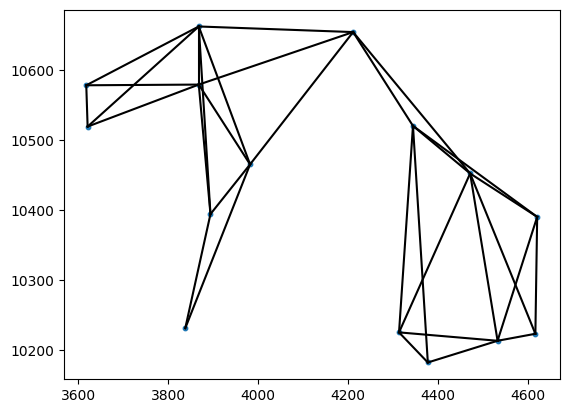

In [432]:
nodes_to_plot = sub_graphs_l[0]
nodes = filtered_points[filtered_points['cell_id'].isin(np.unique(nodes_to_plot))]
plt.scatter(nodes['CenterX_global_px'], nodes['CenterY_global_px'], s=10)
for edge in nodes_to_plot:
    node1 = edge[0]
    node2 = edge[1]
    plt.plot([filtered_points[filtered_points['cell'] == node1]['CenterX_global_px'].values[0], filtered_points[filtered_points['cell'] == node2]['CenterX_global_px'].values[0]],
             [filtered_points[filtered_points['cell'] == node1]['CenterY_global_px'].values[0], filtered_points[filtered_points['cell'] == node2]['CenterY_global_px'].values[0]], c='black')

In [433]:
with open(r'..\..\results\graph_classification_v5\cosmx\sub_graphs_1742.pkl', 'wb') as f:
    pickle.dump(sub_graphs_l, f)

In [434]:
with open(r'..\..\results\graph_classification_v5\cosmx\sub_graphs_1742_cell_index.pkl', 'wb') as f:
    pickle.dump(cells_idx, f)

## 7202-1

In [439]:
filtered_points = pd.read_csv(r'..\..\results\graph_classification_v5\cosmx\cosmx_72021_spatial_annotation_filtered.csv')
unique_edges = pd.read_pickle(r'..\..\results\graph_classification_v5\cosmx\cosmx_72021_spatial_annotation_filtered_edges.pkl')

In [440]:
cells = filtered_points[filtered_points['cell_types'] == 'Stromal']
cells_idx = cells.index.tolist()

In [441]:
sub_graph_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, filtered_points, unique_edges) for cell in cells_idx)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.05014944076538086s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]

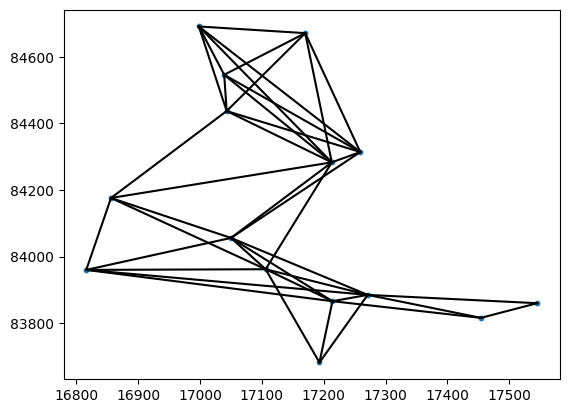

In [443]:
nodes_to_plot = sub_graph_l[0]
nodes = filtered_points[filtered_points['cell_id'].isin(np.unique(nodes_to_plot))]
plt.scatter(nodes['CenterX_global_px'], nodes['CenterY_global_px'], s=10)
for edge in nodes_to_plot:
    node1 = edge[0]
    node2 = edge[1]
    plt.plot([filtered_points[filtered_points['cell_id'] == node1]['CenterX_global_px'].values[0], filtered_points[filtered_points['cell_id'] == node2]['CenterX_global_px'].values[0]],
             [filtered_points[filtered_points['cell_id'] == node1]['CenterY_global_px'].values[0], filtered_points[filtered_points['cell_id'] == node2]['CenterY_global_px'].values[0]], c='black')

In [444]:
with open(r'..\..\results\graph_classification_v5\cosmx\sub_graphs_72021.pkl', 'wb') as f:
    pickle.dump(sub_graph_l, f)

In [445]:
with open(r'..\..\results\graph_classification_v5\cosmx\sub_graphs_72021_cell_index.pkl', 'wb') as f:
    pickle.dump(cells_idx, f)

## 7202-2

In [446]:
filtered_points = pd.read_csv(r'..\..\results\graph_classification_v5\cosmx\cosmx_72022_spatial_annotation_filtered.csv')
unique_edges = pd.read_pickle(r'..\..\results\graph_classification_v5\cosmx\cosmx_72022_spatial_annotation_filtered_edges.pkl')

In [447]:
cells = filtered_points[filtered_points['cell_types'] == 'Stromal']
cells_idx = cells.index.tolist()

In [448]:
sub_graph_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, filtered_points, unique_edges) for cell in cells_idx)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.03759360313415527s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]

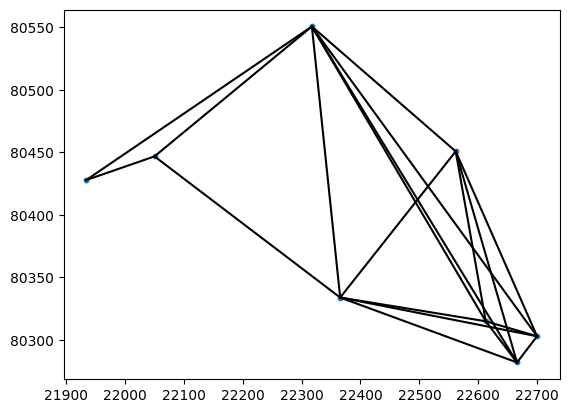

In [449]:
nodes_to_plot = sub_graph_l[0]
nodes = filtered_points[filtered_points['cell_id'].isin(np.unique(nodes_to_plot))]
plt.scatter(nodes['CenterX_global_px'], nodes['CenterY_global_px'], s=10)
for edge in nodes_to_plot:
    node1 = edge[0]
    node2 = edge[1]
    plt.plot([filtered_points[filtered_points['cell'] == node1]['CenterX_global_px'].values[0], filtered_points[filtered_points['cell'] == node2]['CenterX_global_px'].values[0]],
             [filtered_points[filtered_points['cell'] == node1]['CenterY_global_px'].values[0], filtered_points[filtered_points['cell'] == node2]['CenterY_global_px'].values[0]], c='black')

In [450]:
with open(r'..\..\results\graph_classification_v5\cosmx\sub_graphs_72022.pkl', 'wb') as f:
    pickle.dump(sub_graph_l, f)

In [451]:
with open(r'..\..\results\graph_classification_v5\cosmx\sub_graphs_72022_cell_index.pkl', 'wb') as f:
    pickle.dump(cells_idx, f)